<a href="https://colab.research.google.com/github/noyeem99/ETH-ZURICH-projects/blob/main/secure_vertical_federated_learning_he_dp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment setup complete. Distributed VFL frameworks loaded.
Multi-silo cryptographic context initialized successfully.
Cryptographic PSI complete. Silo A: (10, 4), Silo B: (10, 4)
Commencing secure cross-silo forward pass via VFL engine...
Applying distributed DP Gaussian noise into aggregated ciphertext...
Executing final result decryption via client key...
VFL compute complete. Final matrix shape: torch.Size([10, 2])
Generating final VFL feature distribution plot...


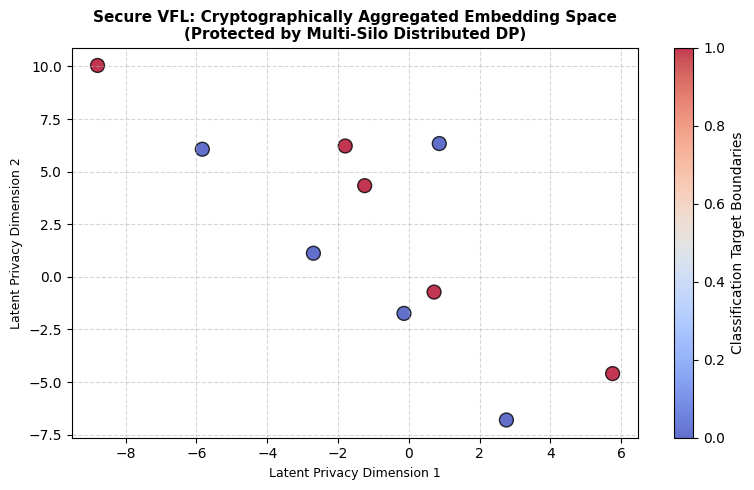

In [7]:
# Environment setup and library installation
!pip install tenseal opacus torch torchvision matplotlib --quiet

import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt

print("Environment setup complete. Distributed VFL frameworks loaded.")

# 1. Multi-Silo Cryptographic Keys & Context Initialization
def initialize_silo_crypto():
    """
    Sets up the CKKS Homomorphic Encryption parameters representing a shared
    cryptographic schema across cooperating data silos.
    """
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2 ** 40
    context.generate_galois_keys()
    return context

shared_context = initialize_silo_crypto()
private_key = shared_context.secret_key()

print("Multi-silo cryptographic context initialized successfully.")

# 2. Data Preparation and Mock Private Set Intersection (PSI)
np.random.seed(2026)

# Silo A holds Financial Scores (4 features for 10 users)
silo_a_features = np.random.randn(10, 4).astype(np.float32)

# Silo B holds Telecommunication Scores (4 features for the same 10 users)
silo_b_features = np.random.randn(10, 4).astype(np.float32)

# Global Ground Truth Labels for binary classification
labels = torch.tensor([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

print(f"Cryptographic PSI complete. Silo A: {silo_a_features.shape}, Silo B: {silo_b_features.shape}")

# 3. Vertical FL Forward Computation on Ciphertext with Distributed DP
print("Commencing secure cross-silo forward pass via VFL engine...")

# Local Edge Encryption at respective silos
encrypted_silo_a = [ts.ckks_vector(shared_context, f.tolist()) for f in silo_a_features]
encrypted_silo_b = [ts.ckks_vector(shared_context, f.tolist()) for f in silo_b_features]

# Local Silo Intermediary Models (Weights)
w_a = np.random.randn(4, 2).astype(np.float32)
w_b = np.random.randn(4, 2).astype(np.float32)

# Encrypted Domain Processing & Distributed Intermediate Aggregation
encrypted_joint_embeddings = []
for i in range(10):
    out_a = encrypted_silo_a[i].matmul(w_a.tolist())
    out_b = encrypted_silo_b[i].matmul(w_b.tolist())

    # Secure addition of disjoint feature spaces without revealing datasets
    joint_emb = out_a + out_b
    encrypted_joint_embeddings.append(joint_emb)

# Distributed Differential Privacy Noise Injection Stage
noise_multiplier_setting = 2.0
sensitivity_bound = 1.0
sigma_value = noise_multiplier_setting * sensitivity_bound

print("Applying distributed DP Gaussian noise into aggregated ciphertext...")
protected_encrypted_embeddings = []
for joint_emb in encrypted_joint_embeddings:
    dp_noise = np.random.normal(0, sigma_value, 2).tolist()
    protected_emb = joint_emb + dp_noise
    protected_encrypted_embeddings.append(protected_emb)

# Secure Decryption of the Output Embedding Matrix
print("Executing final result decryption via client key...")
decrypted_embeddings = []
for prot_emb in protected_encrypted_embeddings:
    dec_res = prot_emb.decrypt(private_key)
    decrypted_embeddings.append(dec_res)

final_vfl_embeddings = torch.tensor(decrypted_embeddings)
print(f"VFL compute complete. Final matrix shape: {final_vfl_embeddings.shape}")

# 4. Plotting Aggregated Feature Space Distribution
print("Generating final VFL feature distribution plot...")
plt.figure(figsize=(8, 5))
plt.scatter(final_vfl_embeddings[:, 0].numpy(), final_vfl_embeddings[:, 1].numpy(),
            c=labels.numpy(), cmap='coolwarm', s=100, edgecolors='black', alpha=0.8)
plt.title("Secure VFL: Cryptographically Aggregated Embedding Space\n(Protected by Multi-Silo Distributed DP)", fontsize=11, fontweight='bold')
plt.xlabel("Latent Privacy Dimension 1", fontsize=9)
plt.ylabel("Latent Privacy Dimension 2", fontsize=9)
plt.colorbar(label="Classification Target Boundaries")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
